In [1]:
import numpy as np
import matplotlib.pyplot as plt

# import jax
# import jax.numpy as jnp
# from jax.config import config

import matplotlib.cm as cm
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, ScalarFormatter
import seaborn as sns
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, ScalarFormatter
plt.rcParams['text.usetex'] = True
from mpl_toolkits.axes_grid1 import make_axes_locatable

from astropy.cosmology import Planck15 as cosmo
from astropy import units as u
import astropy.constants as c
import h5py
import os
import warnings


from gplearn.genetic import SymbolicRegressor
from gplearn.functions import make_function
from gplearn.fitness import make_fitness
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sympy import *
from sklearn.utils.random import check_random_state
import graphviz
import time

In [2]:
converter = {
    'add': lambda x, y : x + y,
    'sub': lambda x, y : x - y,
    'mul': lambda x, y : x*y,
    'div': lambda x, y : x/y,
    'sqrt': lambda x : x**0.5,
    'log': lambda x : log(x),
    'abs': lambda x : abs(x),
    'neg': lambda x : -x,
    'inv': lambda x : 1/x,
    'max': lambda x, y : max(x, y),
    'min': lambda x, y : min(x, y),
    'sin': lambda x : sin(x),
    'cos': lambda x : cos(x),
    'pow': lambda x, y : x**y,
}

In [3]:
def virial_values(M, z, cosmo, mdef = 'vir', quantity='pressure', mu = 0.59): #change quantity from pressure to radius, virial_values for radius
    '''Calculate the virial/normalized values for different quantities of halos
    according to Lau+2015
    Parameters:
       M: halo mass in Msun unit, h=1
       z: redshift
       cosmo: astropy cosmology object
       mdef: mass definition, vir, xxc or xxm
       quantity: virial quantity to calculate,
       radius, pressure, temperature, velocity
       mu: mean particle weigh
    Return:
       virial quantity. Can use .to('xx') to convert to desired units.
       Default units are radius(kpc), P(keV/cm3), T(keV), v(km/s)
    '''
    rho_crit = cosmo.critical_density(z)
    if mdef == 'vir':
        x = cosmo.Om(z) - 1
        delta = 18 * np.pi**2 + 82.0 * x - 39.0 * x**2
        rho = delta*rho_crit
    elif mdef[-1] == 'c':
        delta = int(mdef[:-1])
        rho = delta*rho_crit
    elif mdef[-1] == 'm':
        delta = int(mdef[:-1])
        rho = delta*rho_crit*cosmo.Om(z)
    else:
        raise ValueError("Unsupported mdef")
    fb = cosmo.Ob0/cosmo.Om0
    M = M*u.Msun
    R = ((3*M/(np.pi*4*rho))**(1./3)).to('kpc')
    if quantity=='radius':
        return R
    elif quantity=='pressure':
        return (fb*rho*c.G*M/(2*R)).to('keV/cm3')
    elif quantity=='temperature':
        return (c.G*M*mu*c.m_p/(2*R)).to('keV')
    elif quantity=='velocity':
        return np.sqrt(c.G*M/R).to('km/s')
    else:
        raise ValueError("Unsupported quantity")

def get_halo_keys(my_file):
    """
    Return all group keys in a map analysis file

    Arguments:
      -my_file : The file from which to extract keys
    """

    f  = h5py.File(my_file, 'r')
    fk = list(f.keys())
    f.close()
    fk.sort()
    return fk

def attribute_read(my_file, keys, att):
    """
    Read an attribute for all keys from a file

    Arguments:
      -my_file : The file from which to read
      -keys    : File keys to examine
      -att     : Attribute to read for each key

    Returns:
      -data : A 1D array containing all attributes read
    """

    f    = h5py.File(my_file, 'r')
    data = np.zeros(len(keys))
    for j in range(0, len(keys), 1):
        data[j] = f[keys[j]].attrs[att]
    f.close()
    return data

def dataset_read(my_file, keys, dset):
    """
    Read an attribute for all keys from a file

    Arguments:
      -my_file : The file from which to read
      -keys    : File keys to examine
      -dset    : Dataset to read for each key

    Returns:
      -data : A 2D array where each row is a dataset
    """

    f     = h5py.File(my_file, 'r')
    shape = f[keys[0]][dset].shape
    if len(shape) == 1:
        data  = np.zeros((len(keys), shape[0]), dtype=np.float64)
    elif len(shape) == 2:
        data  = np.zeros((len(keys), shape[0], shape[1]), dtype=np.float64)

    for j in range(0, len(keys), 1): data[j] = f[keys[j]][dset][:]
    f.close()
    del shape
    return data

In [4]:
def tng_profiles_all(tng_data_file):
    filename = tng_data_file
    halo_ids = np.array(get_halo_keys(filename))
    mass = attribute_read(filename, halo_ids, 'M200_Msun')
    mass_select_mask = (mass>0) & (mass>0) # taking all masses
    mass_select = mass[mass_select_mask]
    return mass_select


def tng_profiles(tng_data_file, log_M0):

    '''
    Input:
        tng_data_file = variable defined as the datafile path
        log(M0) = median mass, ex. 14.0

    Outputs:
        TNG_Qdm: intermediate-major axis (b/c) for DM
        TNG_Qgas: intermediate-major axis (b/c) for gas
        TNG_Sdm: minor-major axis (a/c) for DM
        TNG_Sgas: minor-major axis (a/c) for gas
        TNG_fnth: non-thermal pressure fraction
    '''

    filename = tng_data_file
    if log_M0 >= 14.5:
        lower_mass, higher_mass = (log_M0), (log_M0 + 0.5)
    else:
        lower_mass, higher_mass = (log_M0 - 0.1), (log_M0 + 0.1) # mass bin

    halo_ids = np.array(get_halo_keys(filename))
    mass = attribute_read(filename, halo_ids, 'M200_Msun')
    rad = attribute_read(filename, halo_ids, 'R200_Mpc') # do this div by virial_values
    rvir = attribute_read(filename, halo_ids, 'Rvir_Mpc')
    conc = attribute_read(filename, halo_ids, 'Cvir')
    # macc = attribute_read(filename, halo_ids, 'Macc_200c')

    #mass_select_mask = (mass>10**13.0) & (mass<10**13.2)
    mass_select_mask = (mass>10**lower_mass) & (mass<10**higher_mass) # taking all masses
    halo_ids_select = halo_ids[mass_select_mask] # each halo within the TNG catalog is given a ID
    #print('Number of halos between %s - %s'%(lower_mass, higher_mass),len(halo_ids_select))
    mass_select = mass[mass_select_mask]
    rad_select = rad[mass_select_mask]
    rvir_select = rvir[mass_select_mask]
    conc_select = conc[mass_select_mask]
    # macc_select = macc[mass_select_mask]

    TNGm = dataset_read(filename, halo_ids_select, 'Mgas_Msun')*u.Msun
    Xoff = attribute_read(filename, halo_ids, 'Xoff') # distance between center of mass and minimum gravitational energy
    TNGv = dataset_read(filename, halo_ids_select, 'Volumes_Mpc^3')*u.Mpc**3
    TNGT = dataset_read(filename, halo_ids_select, 'Tmw_keV')*u.keV
    TNGr = dataset_read(filename, halo_ids_select, 'Radii_Mpc')*u.Mpc
    TNGnth = (dataset_read(filename, halo_ids_select, 'Pnth_erg_cm^-3')*u.erg/u.cm**3)/3.

    TNG_Qdm = dataset_read(filename, halo_ids_select, 'Qdm')
    TNG_Qgas = dataset_read(filename, halo_ids_select, 'Qgas')

    TNG_Sdm = dataset_read(filename, halo_ids_select, 'Sdm')
    TNG_Sgas = dataset_read(filename, halo_ids_select, 'Sgas')

    mu = 0.59
    xoff_select = Xoff[mass_select_mask]
    TNGrho = TNGm/TNGv
    TNGPth = (TNGrho*TNGT/(mu*c.m_p))
    TNGPtot = TNGPth + TNGnth
    # TNGPtot_select = TNGPtot[mass_select_mask]
    TNGnr = TNGr/(rad_select[:,None]*u.Mpc)

    # changed mdef=200c to mdef=200m
    TNG_pressure_array = (TNGPth/virial_values(mass_select, 0, cosmo, mdef='200m', quantity='pressure')[:,None]).to('')
    TNG_ptot_array = (TNGPtot/virial_values(mass_select, 0, cosmo, mdef='200m', quantity='pressure')[:,None]).to('')
    TNG_rho_array = (TNGrho/ mu / c.m_p).to('/cm3').value
    TNG_T_array = (TNGT/virial_values(mass_select, 0, cosmo, mdef='200m', quantity='temperature')[:,None]).to('')

    TNG_fnth = 1 - (TNG_pressure_array/TNG_ptot_array)

    return TNGnr[0], TNG_Qdm, TNG_Qgas, TNG_Sdm, TNG_Sgas, TNG_fnth

def TNG_percentiles(tng_data_file, log_M0, percentile):

    _, TNG_Qdm, TNG_Qgas, TNG_Sdm, TNG_Sgas, TNG_fnth, = tng_profiles(tng_data_file, log_M0)

    TNG_Qdm_pct = np.percentile(TNG_Qdm, percentile, axis=0)
    TNG_Qgas_pct = np.percentile(TNG_Qgas, percentile, axis=0)
    TNG_Sdm_pct = np.percentile(TNG_Sdm, percentile, axis=0)
    TNG_Sgas_pct = np.percentile(TNG_Sgas, percentile, axis=0)
    TNG_fnth_pct = np.percentile(TNG_fnth, percentile, axis=0)
   # TNG_ms_pct = jnp.percentile(TNGms, percentile, axis=0)
   # TNG_conc_pct = jnp.percentile(conc, percentile, axis=0)

    return TNG_Qdm_pct, TNG_Qgas_pct, TNG_Sdm_pct, TNG_Sgas_pct, TNG_fnth_pct

In [5]:
def zstring_to_decimal(z):
    zee = z[0] + '.' + z[1:]
    return float(zee)

def get_shapes(m, z, percentile=50, islog=False):

  #m = str(m) # log of halo mass eg: 13.0 with quotes
  #z = str(z) # redshift without decimal (000, 050, etc.) eg: "000" with quotes

  datafile = []
  # '/content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5'

  if z == "000":
    datafile = "TNG300-1_z0.00_gas.hdf5"
  if z == "050":
    datafile = "TNG300-1_z0.50_gas.hdf5"
  if z == "103":
    datafile = "TNG300-1_z1.03_gas.hdf5"

  print("datafile:",datafile)
  print("halo mass:", m)
  print("redshift:", z)

  rad_var, qdm_var, _, sdm_var, _, _, = tng_profiles(datafile, m)
  qdm_var, _, sdm_var, _, _, = TNG_percentiles(datafile, m, percentile)

  nsample = 1000
  sig = 0.2

  rad_var_new = np.linspace(rad_var[0], rad_var[-1], nsample)
  qdm_var_new = np.interp(rad_var_new, rad_var, qdm_var)
  sdm_var_new = np.interp(rad_var_new, rad_var, sdm_var)

  rad_var_nlog = np.log10(rad_var_new)
  qdm_var_nlog = np.log10(qdm_var_new)
  sdm_var_nlog = np.log10(sdm_var_new)

  if islog == True:
    return rad_var_nlog, qdm_var_nlog, sdm_var_nlog

  return rad_var_new, qdm_var_new, sdm_var_new

def get_train(m_array, z_array, percentile=50, islog=False):

  X_train = []
  y_train_qdm = []
  y_train_sdm = []

  for m in m_array:
    for z in z_array:
      rad_var_new, qdm_var_new, sdm_var_new = get_shapes(m, z, percentile, islog=islog)
      zee = zstring_to_decimal(z)
      X_train.append(np.column_stack((rad_var_new, np.full_like(rad_var_new, m), np.full_like(rad_var_new, zee))))
      y_train_qdm.append(qdm_var_new)
      y_train_sdm.append(sdm_var_new)

  X_train = np.vstack(X_train)
  y_train_qdm = np.hstack(y_train_qdm)
  y_train_sdm = np.hstack(y_train_sdm)

  return X_train, y_train_qdm, y_train_sdm

In [59]:
print(X_train_rad)
print(y_train_qdm)

[[-1.26103    13.          0.        ]
 [-1.22669894 13.          0.        ]
 [-1.19488406 13.          0.        ]
 ...
 [ 0.65811015 14.          1.03      ]
 [ 0.65854029 14.          1.03      ]
 [ 0.65897    14.          1.03      ]]
[-0.0382509  -0.03794346 -0.03763624 ... -1.07297759 -1.0736777
 -1.07437893]


In [50]:
rad_var_new, qdm_var_new, sdm_var_new = get_shapes(13.0, "050")

datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.0
redshift: 050


In [51]:
nan_in_qdm_var_new = np.isnan(qdm_var_new)

if np.any(qdm_var_new):
    print("NaNs found in qdm_var_new")
    print("NaN positions in qdm_var_new:", np.where(nan_in_qdm_var_new))

NaNs found in qdm_var_new
NaN positions in qdm_var_new: (array([323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335,
       336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348,
       349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361,
       362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374,
       375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387,
       388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400,
       401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413,
       414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426,
       427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439,
       440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452,
       453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465,
       466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478,
       479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491,
       

In [6]:
def get_next_filename(base_path):

    '''
    Use with any existing plotting function to save the next numerical iteration
    directly in the same directory without overwriting current figure.
    '''

    base, ext = os.path.splitext(base_path)
    i = 1
    new_path = base_path
    while os.path.exists(new_path):
        new_path = f"{base}_{i}{ext}"
        i += 1
    return new_path

In [7]:
def plot_shape(z):

  logM0 = np.array((13.0, 13.5, 14.0))
  colors = sns.color_palette("flare", n_colors=3)

  fig, ax = plt.subplots(1,1)

  for idx, i in enumerate(logM0):
    radius_plot, qdm_plot, sdm_plot = get_shapes(i, z)
    ax.semilogx(radius_plot, qdm_plot, label=r'$\log(M) = {}$'.format(i), color=colors[idx])

  basedir = "/Users/demiant/diffshape/"
  file_path = basedir + 'shape_plot_%s.png'%(z)
  file_path = get_next_filename(file_path)
  print("filepath:", file_path)

  plt.savefig(file_path, bbox_inches='tight', dpi=300)

def plot_shapes(qdm=None, sdm=None, error=13.0, pred_m=0, islog=False):

  logM0 = np.array((13.0, 13.5, 14.0))
  colors = sns.color_palette("flare", n_colors=3)
  predc = sns.color_palette("crest", n_colors=3)
  z_array = np.array(("000", "050", "103"))

  fig, ((ax11, ax21, ax31), (ax12, ax22, ax32)) = plt.subplots(2, 3, figsize=(9, 6), sharex=True, layout='tight')
  ax = np.array((ax11, ax12, ax21, ax22, ax31, ax32))

  for color, m in enumerate(logM0):
    j = 0
    for z in z_array:
      radius_plot, qdm_plot, sdm_plot = get_shapes(m, z, 50, islog=islog)

      if qdm is not None and sdm is not None:
        zee = zstring_to_decimal(z)
        radius_pred = np.column_stack((radius_plot, np.full_like(radius_plot, pred_m), np.full_like(radius_plot, zee)))
        qdm_pred = qdm.predict(radius_pred)
        sdm_pred = sdm.predict(radius_pred)


      if islog:
        ax[j].plot(radius_plot, qdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])
        ax[j + 1].plot(radius_plot, sdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])

        if (pred_m == m):
            
          mask = (radius_pred[:, 0] >= -1.0) 
          radius_pred_masked = radius_pred[mask]
          qdm_pred_masked = qdm_pred[mask]
          sdm_pred_masked = sdm_pred[mask]

          ax[j].plot(radius_pred_masked[:,0], qdm_pred_masked, label=r'$\log(M) = {} \,\, \rm prediction$'.format(pred_m), color=predc[1])
          ax[j + 1].plot(radius_pred_masked[:,0], sdm_pred_masked, color=predc[1])

        ax[j].set_ylim(-1, 0)
        ax[j + 1].set_ylim(-1, 0)
        ax[j].set_xlim(-1.4, 0.7)
        ax[j + 1].set_xlim(-1.4, 0.7)
        ax[j + 1].set_xlabel(r'$\log(r/R_{\rm 200c})$', fontsize=20)

      else:
        ax[j].semilogx(radius_plot, qdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])
        ax[j + 1].semilogx(radius_plot, sdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])
        
        if (pred_m == m):
    
          ax[j].semilogx(radius_pred_masked[:,0], qdm_pred_masked, label=r'$\log(M) = {} \,\, \rm prediction$'.format(pred_m), color=predc[1])
          ax[j + 1].semilogx(radius_pred_masked[:,0], sdm_pred_masked, color=predc[1])
        
        ax[j].set_ylim(0, 1)
        ax[j].axvline(x=1, color='grey', linestyle='--')
        ax[j + 1].axvline(x=1, color='grey', linestyle='--')
        ax[j + 1].set_xlabel(r'$r/R_{\rm 200c}$', fontsize=20)

      ax[j].yaxis.set_tick_params(labelsize=16)
      formatted_z = f"{z[0]}.{z[1:]}"
      ax[j].set_title(r'$z = %s$' % formatted_z, fontsize=20)
      ax[j].tick_params(which='both', axis='both', direction='in')
      ax[j].xaxis.set_tick_params(labelbottom=False)

      ax[j + 1].sharey(ax[j])
      ax[j + 1].tick_params(which='both', axis='both', direction='in')
      ax[j + 1].xaxis.set_tick_params(labelsize=16)

      if m == error:
        _, qdm_plot_u, sdm_plot_u = get_shapes(m, z, 84, islog)
        _, qdm_plot_l, sdm_plot_l = get_shapes(m, z, 16, islog)
        ax[j].fill_between(radius_plot, qdm_plot_l, qdm_plot_u, color=colors[color], alpha=0.2)
        ax[j + 1].fill_between(radius_plot, sdm_plot_l, sdm_plot_u, color=colors[color], alpha=0.2)

      if j > 0:
        ax[j].yaxis.set_tick_params(labelleft=False)
        ax[j + 1].yaxis.set_tick_params(labelleft=False)

      j += 2

  if islog==True:
    ax11.set_ylabel(r'$\log(Q_{\rm dm, med})$', fontsize=20)
    ax12.set_ylabel(r'$\log(S_{\rm dm, med})$', fontsize=20)
  else:
    ax11.set_ylabel(r'$Q_{\rm dm, med}$', fontsize=20)
    ax12.set_ylabel(r'$S_{\rm dm, med}$', fontsize=20)

  ax11.legend(loc='lower left', fontsize=12)
  ax11.yaxis.set_tick_params(labelsize=16)
  ax12.yaxis.set_tick_params(labelsize=16)

  basedir = "/Users/demiant/diffshape/"
  file_path = basedir + 'six_plot_shapes.png'
  file_path = get_next_filename(file_path)
  print("filepath:", file_path)

  plt.savefig(file_path, bbox_inches='tight', dpi=300)

In [ ]:
radius_plot, qdm_plot, sdm_plot = get_shapes(13.5, "000", 50, islog=True)
radius_pred = np.column_stack((radius_plot, np.full_like(radius_plot, 13.5), np.full_like(radius_plot, 0)))
qdm_pred = est_qdm.predict(radius_pred)
sdm_pred = est_sdm.predict(radius_pred)

mask = (radius_pred >= -1.0) & (radius_pred <= 0.7)
radius_pred_masked = radius_pred[mask.any(axis=1)]
qdm_pred_masked = qdm_pred[mask.any(axis=1)]
sdm_pred_masked = sdm_pred[mask.any(axis=1)]

datafile: /content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000


<ipython-input-4-7cfc9333dd9d>:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  data[j] = f[keys[j]].attrs[att]


In [ ]:

print(X_train_rad)


[[-1.26103    13.          0.        ]
 [-1.22669894 13.          0.        ]
 [-1.19488406 13.          0.        ]
 ...
 [ 0.65811015 14.          1.03      ]
 [ 0.65854029 14.          1.03      ]
 [ 0.65897    14.          1.03      ]]


datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.0
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 14.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 14.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 14.0
redshift: 103
filepath: /Users/demiant/diffshape/six_p

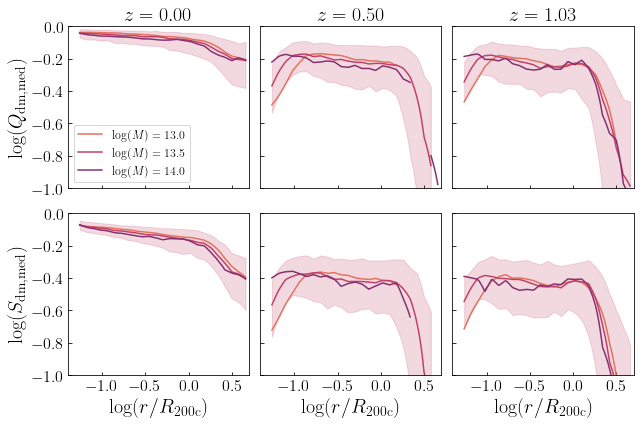

In [32]:
plot_shapes(error=13.5, islog=True)

In [49]:
def _protected_power(x1, x2):
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        result = np.where(
            (np.abs(x1) < 100) & (np.abs(x2) < 100) & ((x1 >= 0) | (np.floor(x2) == x2)),
            np.power(x1, x2),
            0.
        )
        return np.where(np.isfinite(result), result, 0.)

ppow = make_function(function=_protected_power, name='pow', arity=2)

def _cbrt(x1):
    return np.cbrt(x1)
cbrt = make_function(function=_cbrt, name='cbrt',arity=1)

def pow_3(x1):
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        result = np.where(
            (np.abs(x1) < 100) & ((x1 >= 0)),
            np.power(x1, 3),
            0.
        )
        return np.where(np.isfinite(result), result, 0.)
pow_3 = make_function(function=pow_3,name='pow3',arity=1)

def _mape_with_penalty(y, y_pred, w):
    """Calculate the mean absolute percentage error with harsh punishment for values outside [0, 1]."""
    # Original MAPE calculation
    diffs = np.abs(np.divide((np.maximum(0.001, y) - np.maximum(0.001, y_pred)),
                             np.maximum(0.001, y)))
    mape = 100. * np.average(diffs, weights=w)

    # Penalty for predictions outside [0, 1]
    penalty = np.sum((y_pred < 0) | (y_pred > 1)) * 1e6

    return mape + penalty

def _mae_with_penalty(y, y_pred, w):
    """Calculate the mean absolute error with harsh punishment for any positive predicted values."""
    # MAE calculation
    diffs = np.abs(y - y_pred)
    mae = np.average(diffs, weights=w)

    # Penalty for predictions with any positive values
    penalty = np.sum((y_pred > 0)) * 1e6  # Apply a large penalty (1e6) for any value greater than 0

    return mae + penalty

mape = make_fitness(function=_mape_with_penalty,
                    greater_is_better=False)
mae_with_penalty = make_fitness(function=_mae_with_penalty, greater_is_better=False)

In [89]:
def perform_sr(X_train, y_train):

  valid_indices = ~np.isnan(y_train)
  X_train = X_train[valid_indices]
  y_train = y_train[valid_indices]

  with warnings.catch_warnings():
      warnings.simplefilter("ignore", RuntimeWarning)

      est_gp = SymbolicRegressor(init_depth=(2, 6),
                                population_size=50000,
                                generations=50, stopping_criteria=0.01,
                                p_crossover=0.6, p_subtree_mutation=0.2,
                                p_hoist_mutation=0.05, p_point_mutation=0.15,
                                metric=mae_with_penalty,
                                function_set=('add', 'sub', 'mul', 'div'),
                                max_samples=0.9, verbose=1,
#                                 const_range=(-5, 5),
                                parsimony_coefficient=0.0001, random_state=0,n_jobs=-1)
      est_gp.fit(X_train, y_train)

  next_e = sympify(str(est_gp._program), locals=converter)
  next_e = next_e.subs({'X0': 'R', 'X1': 'M', 'X2': 'z'})

  return est_gp, next_e

def regress_further(X_train, y_train, est_gp, trials):

  valid_indices = ~np.isnan(y_train)
  X_train = X_train[valid_indices]
  y_train = y_train[valid_indices]

  est_gp.set_params(generations=trials, warm_start=True)
  est_gp.fit(X_train, y_train)

  next_e = sympify(str(est_gp._program), locals=converter)
  next_e = next_e.subs({'X0': 'R', 'X1': 'M', 'X2': 'z'})

  return est_gp, next_e

In [31]:
m_array = np.array((13.0, 13.5, 14.0))
z_array = np.array(("000", "050", "103"))

X_train_rad, y_train_qdm, y_train_sdm = get_train(m_array, z_array, islog=True)

datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.0
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 14.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 14.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 14.0
redshift: 103


In [10]:
print(X_train_rad.shape)
print(y_train_qdm.shape)

(9000, 3)
(9000,)


In [11]:
mask = X_train_rad[:, 0] >= 0.1
X_train_rad = X_train_rad[mask]
y_train_qdm = y_train_qdm[mask]
y_train_sdm = y_train_sdm[mask]

In [39]:
print(X_train_rad.shape)

(9000, 3)


In [32]:
est_qdm, qdm_e = perform_sr(X_train_rad, y_train_qdm)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    17.66      5.35579e+09       20         0.109924         0.111682      5.48m
   1    16.51      2.17017e+09       20        0.0885971        0.0928587      5.44m
   2    13.24      2.14083e+09       22        0.0799398        0.0834097      5.89m
   3    11.51      2.13728e+09       26        0.0600053        0.0590037      6.61m
   4    14.28      1.94052e+09       34        0.0535706        0.0528085      5.86m
   5    19.64      1.57081e+09       25        0.0511825         0.049967      6.12m
   6    21.67      1.45537e+09       48        0.0508043        0.0536919      7.98m
   7    22.98      1.42689e+09       31        0.0476161        0.0493841      7.95m
   8    23.32      1.42521e+09       36        0.0454784        0.0459867  

In [33]:
est_qdm2, qdm_e2 = regress_further(X_train_rad, y_train_qdm, est_qdm, 100)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
  20    15.22      1.83192e+09       28        0.0353036        0.0356139     47.99m
  21    15.34      1.81126e+09       28         0.035106        0.0373906     35.90m
  22    16.72      1.72096e+09       29        0.0349474        0.0349892     45.94m
  23    19.43      1.50693e+09       29        0.0348169        0.0361632     41.45m
  24    21.51       1.3202e+09       24        0.0344678         0.037166     35.11m
  25    21.97      1.25057e+09       26        0.0343746        0.0368353     43.05m
  26    22.14      1.24955e+09       25        0.0344092        0.0332387     35.96m
  27    22.26      1.23787e+09       25        0.0341157        0.0358777     40.29m
  28    22.50      1.21369e+09       25        0.0340478        0.0364878  

In [34]:
qdm_e

0.352*R*(-0.285*R*z - 0.285*R - z**0.0625)/(R - Abs(R)) - 1.246/Abs(M)

In [117]:
sympy.saveimage(qdm_e, qdm_e.png)

NameError: name 'sympy' is not defined

In [108]:
est_sdm, sdm_e = perform_sr(X_train_rad, y_train_sdm)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    17.79      5.35791e+09       93         0.159435         0.168291      6.53m
   1    16.66      2.17723e+09       26         0.139613         0.136976     12.22m
   2    13.29      2.07943e+09       21          0.12205         0.121901     25.36m
   3    17.13      1.91706e+09       94        0.0940154        0.0972345     12.63m
   4    24.63      1.60986e+09      102        0.0896152        0.0858528     14.76m
   5    19.31      1.50877e+09      113        0.0842337        0.0852644     16.68m
   6    21.46      1.32272e+09      100        0.0726355         0.074447     25.45m
   7    24.02      1.18664e+09      108        0.0680607        0.0656804     18.36m
   8    25.09      1.12882e+09       90        0.0588634        0.0615145  

In [110]:
sdm_e

(-0.415*z**0.25 - 0.415*(-R*((z**0.25*(R + 0.758))**0.125*(R + 0.758))**0.5 + 0.256)**0.5)*(R + Abs(R) + 0.635)

datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.0
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 14.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 14.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 14.0
redshift: 103
filepath: /Users/demiant/diffshape/six_p

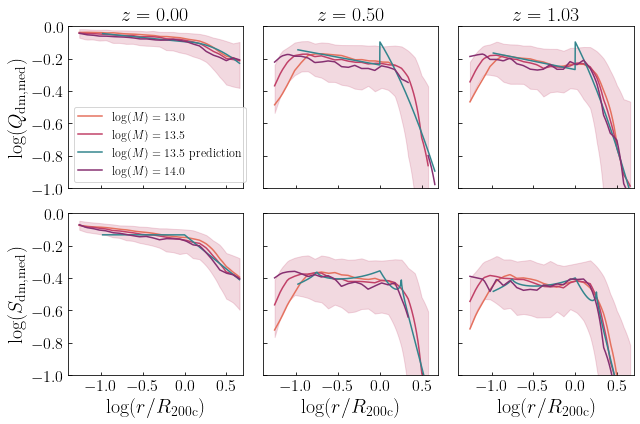

In [113]:
plot_shapes(est_qdm, est_sdm, error=13.5, pred_m=13.5, islog=True)

In [55]:
def get_ratios(m, z, percentile=50, islog=False):

  #m = str(m) # log of halo mass eg: 13.0 with quotes
  #z = str(z) # redshift without decimal (000, 050, etc.) eg: "000" with quotes

  datafile = []
  # '/content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5'

  if z == "000":
    datafile = "TNG300-1_z0.00_gas.hdf5"
  if z == "050":
    datafile = "TNG300-1_z0.50_gas.hdf5"
  if z == "103":
    datafile = "TNG300-1_z1.03_gas.hdf5"

  print("datafile:",datafile)
  print("halo mass:", m)
  print("redshift:", z)

  rad_var, qdm_var, _, sdm_var, _, _, = tng_profiles(datafile, m)
  qdm_var, _, sdm_var, _, _, = TNG_percentiles(datafile, m, percentile)

  nsample = 1000
  sig = 0.2

  rad_var_new = np.linspace(rad_var[0], rad_var[-1], nsample)
  qdm_var_new = np.interp(rad_var_new, rad_var, qdm_var)
  sdm_var_new = np.interp(rad_var_new, rad_var, sdm_var)
  sdm_qdm_var_new = np.divide(sdm_var_new,qdm_var_new)

  rad_var_nlog = np.log10(rad_var_new)
  sdm_var_nlog = np.log10(sdm_var_new)
  sdm_qdm_var_nlog = np.log10(sdm_qdm_var_new)

  if islog == True:
    return rad_var_nlog, sdm_var_nlog, sdm_qdm_var_nlog

  return rad_var_new, sdm_var_new, sdm_qdm_var_new

def get_train_ratios(m_array, z_array, percentile=50, islog=False):

  X_train = []
  y_train_sdm = []
  y_train_sdm_qdm = []

  for m in m_array:
    for z in z_array:
      rad_var_new, sdm_var_new, sdm_qdm_var_new = get_ratios(m, z, islog=islog)
      zee = zstring_to_decimal(z)
      X_train.append(np.column_stack((rad_var_new, np.full_like(rad_var_new, m), np.full_like(rad_var_new, zee))))
      y_train_sdm.append(sdm_var_new)
      y_train_sdm_qdm.append(sdm_qdm_var_new)

  X_train = np.vstack(X_train)
  y_train_sdm = np.hstack(y_train_sdm)
  y_train_sdm_qdm = np.hstack(y_train_sdm_qdm)

  return X_train, y_train_sdm, y_train_sdm_qdm

In [11]:
def plot_ratios(sdm=0, sdm_qdm=0, error=13.0, pred_m=0, islog=False):

  logM0 = np.array((13.0, 13.5, 14.0))
  colors = sns.color_palette("flare", n_colors=3)
  predc = sns.color_palette("crest", n_colors=3)
  z_array = np.array(("000", "050", "103"))

  fig, ((ax11, ax21, ax31), (ax12, ax22, ax32)) = plt.subplots(2, 3, figsize=(9, 6), sharex=True, layout='tight')
  ax = np.array((ax11, ax12, ax21, ax22, ax31, ax32))

  for color, m in enumerate(logM0):
    j = 0
    for z in z_array:
      radius_plot, sdm_plot, sdm_qdm_plot = get_ratios(m, z, 50, islog=islog)

      zee = zstring_to_decimal(z)
      radius_pred = np.column_stack((radius_plot, np.full_like(radius_plot, pred_m), np.full_like(radius_plot, zee)))
      sdm_pred = sdm.predict(radius_pred)
      sdm_qdm_pred = sdm_qdm.predict(radius_pred)


      if islog:
        ax[j].plot(radius_plot, sdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])
        ax[j + 1].plot(radius_plot, sdm_qdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])

        if (pred_m == m):
            
          mask = (radius_pred[:, 0] >= -1.0) 
          radius_pred_masked = radius_pred[mask]
          sdm_pred_masked = sdm_pred[mask]
          sdm_qdm_pred_masked = sdm_qdm_pred[mask]

          ax[j].plot(radius_pred_masked[:,0], sdm_pred_masked, label=r'$\log(M) = {} \,\, \rm prediction$'.format(pred_m), color=predc[1])
          ax[j + 1].plot(radius_pred_masked[:,0], sdm_qdm_pred_masked, color=predc[1])

        ax[j].set_ylim(-1, 0)
        ax[j + 1].set_ylim(-1, 0)
        ax[j].set_xlim(-1.4, 0.7)
        ax[j + 1].set_xlim(-1.4, 0.7)
        ax[j + 1].set_xlabel(r'$\log(r/R_{\rm 200c})$', fontsize=20)

      else:
        ax[j].semilogx(radius_plot, sdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])
        ax[j + 1].semilogx(radius_plot, sdm_qdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])
        
#         if (pred_m == m):
    
#           ax[j].semilogx(radius_pred_masked[:,0], qdm_pred_masked, label=r'$\log(M) = {} \,\, \rm prediction$'.format(pred_m), color=predc[1])
#           ax[j + 1].semilogx(radius_pred_masked[:,0], sdm_pred_masked, color=predc[1])
        
        ax[j].set_ylim(0, 1)
        ax[j].axvline(x=1, color='grey', linestyle='--')
        ax[j + 1].axvline(x=1, color='grey', linestyle='--')
        ax[j + 1].set_xlabel(r'$r/R_{\rm 200c}$', fontsize=20)

      ax[j].yaxis.set_tick_params(labelsize=16)
      formatted_z = f"{z[0]}.{z[1:]}"
      ax[j].set_title(r'$z = %s$' % formatted_z, fontsize=20)
      ax[j].tick_params(which='both', axis='both', direction='in')
      ax[j].xaxis.set_tick_params(labelbottom=False)

      ax[j + 1].sharey(ax[j])
      ax[j + 1].tick_params(which='both', axis='both', direction='in')
      ax[j + 1].xaxis.set_tick_params(labelsize=16)

      if m == error:
        _, sdm_plot_u, sdm_qdm_plot_u = get_ratios(m, z, 84, islog)
        _, sdm_plot_l, sdm_qdm_plot_l = get_ratios(m, z, 16, islog)
        ax[j].fill_between(radius_plot, sdm_plot_l, sdm_plot_u, color=colors[color], alpha=0.2)
        ax[j + 1].fill_between(radius_plot, sdm_qdm_plot_l, sdm_qdm_plot_u, color=colors[color], alpha=0.2)

      if j > 0:
        ax[j].yaxis.set_tick_params(labelleft=False)
        ax[j + 1].yaxis.set_tick_params(labelleft=False)

      j += 2

  if islog==True:
    ax11.set_ylabel(r'$\log(S_{\rm dm, med})$', fontsize=20)
    ax12.set_ylabel(r'$\log(S_{\rm dm, med}/Q_{\rm dm, med})$', fontsize=20)
  else:
    ax11.set_ylabel(r'$S_{\rm dm, med}$', fontsize=20)
    ax12.set_ylabel(r'$S_{\rm dm, med}/Q_{\rm dm, med}$', fontsize=20)

  ax11.legend(loc='lower left', fontsize=12)
  ax11.yaxis.set_tick_params(labelsize=16)
  ax12.yaxis.set_tick_params(labelsize=16)

  basedir = "/Users/demiant/diffshape/"
  file_path = basedir + 'with_ratios_plot_shapes.png'
  file_path = get_next_filename(file_path)
  print("filepath:", file_path)

  plt.savefig(file_path, bbox_inches='tight', dpi=300)

datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.0
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 14.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 14.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 14.0
redshift: 103
filepath: /Users/demiant/diffshape/with_

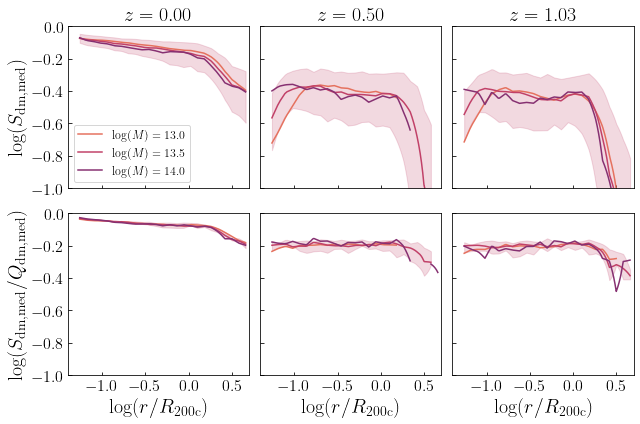

In [124]:
plot_ratios(error=13.5,islog=True)

In [56]:
m_array = np.array((13.0, 13.5, 14.0))
z_array = np.array(("000", "050", "103"))

X_train_rad, y_train_sdm, y_train_sdm_qdm = get_train_ratios(m_array, z_array, islog=True)

datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.0
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 14.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 14.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 14.0
redshift: 103


In [25]:
scatter_000 = (X_train_rad[:,2] == 0)
scatter_050 = (X_train_rad[:,2] == 0.50)
scatter_103 = (X_train_rad[:,2] == 1.03)

In [38]:
print(sdm_plot_u_000.shape)

(1000,)


In [26]:
scatter_103

array([False, False, False, ...,  True,  True,  True])

In [40]:
def _mae_with_penalty_sdm(y, y_pred, w):
    """Calculate the mean absolute error with harsh punishment for any positive predicted values."""
    # MAE calculation
    diffs = np.abs(y - y_pred)
    mae = np.average(diffs, weights=w)

    # Penalty for predictions with any positive values
    penalty = np.sum((y_pred > 0) | (y_pred[scatter_000] > sdm_plot_u_000) | (y[scatter_000] < sdm_plot_l_000)) * 1e6  # Apply a large penalty (1e6) for any value greater than 0

    return mae + penalty

mae_with_penalty_sdm = make_fitness(function=_mae_with_penalty_sdm, greater_is_better=False)

In [20]:
_, sdm_plot_u_000, sdm_qdm_plot_u_000 = get_ratios(13.5, "000", 84, islog=True)
_, sdm_plot_l_000, sdm_qdm_plot_l_000 = get_ratios(13.5, "000", 16, islog=True)

_, sdm_plot_u_050, sdm_qdm_plot_u_050 = get_ratios(13.5, "050", 84, islog=True)
_, sdm_plot_l_050, sdm_qdm_plot_l_050 = get_ratios(13.5, "050", 16, islog=True)

_, sdm_plot_u_103, sdm_qdm_plot_u_103 = get_ratios(13.5, "103", 84, islog=True)
_, sdm_plot_l_103, sdm_qdm_plot_l_103 = get_ratios(13.5, "103", 16, islog=True)

datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103


In [81]:
mask = X_train_rad[:,0] >= -1.0

In [82]:
X_train_rad = X_train_rad[mask]
y_train_sdm = y_train_sdm[mask]
y_train_sdm_qdm = y_train_sdm_qdm[mask]

In [18]:
print(X_train_rad.shape)
print(y_train_sdm_qdm.shape)

(7524, 3)
(7524,)


In [ ]:
sdm_plot_u, sdm_qdm_plot_u = get_ratios(m, z, 84, islog)
sdm_plot_l, sdm_qdm_plot_l = get_ratios(m, z, 16, islog)

In [87]:
est_sdm, sdm_e = perform_sr(X_train_rad, y_train_sdm)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    33.37      4.17411e+08        7         0.142102        0.0858553      6.05m
   1    18.11      5.35297e+07       39         0.126076         0.110475     13.50m
   2    12.73      5.16448e+07       11         0.115274         0.147991     14.63m
   3    12.92      4.71823e+07       35        0.0997967         0.138696     14.16m
   4    13.51      4.47114e+07       47        0.0892679        0.0793632     14.08m
   5    17.67      4.54532e+07       35        0.0796891          0.12468     15.33m
   6    20.02      4.65523e+07       37         0.074669        0.0831736     15.01m
   7    26.14      4.15518e+07       37        0.0631684         0.110277     39.02m
   8    32.63      4.10947e+07       41        0.0563168         0.050651  

In [88]:
sdm_e

(0.200028*M + 3*z + 0.589616464 + 0.498/z)/(M*R - M) + R*(1.472 + 0.498/z)/M

In [22]:
est_sdm2, sdm_e2 = regress_further(X_train_rad, y_train_sdm, est_sdm, 100)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
  50    28.73      1.40672e+09       31        0.0361751        0.0401896     32.95m
  51    28.75      1.40727e+09       31        0.0361822        0.0401256     27.31m
  52    28.78       1.4025e+09       31        0.0361351          0.04055     26.76m
  53    28.70      1.39567e+09       31        0.0362602         0.039424     28.42m
  54    28.58      1.39817e+09       31        0.0362304        0.0396924     28.66m
  55    28.34      1.40225e+09       31        0.0361637        0.0402927     26.39m
  56    28.02      1.42706e+09       31        0.0361926        0.0400322     25.25m
  57    27.22      1.42765e+09       31        0.0363348        0.0387531     26.91m
  58    26.90      1.42368e+09       31        0.0364607        0.0376202  

In [23]:
sdm_e2

(-1.501*R**2 + (R + 1.299)/(-R/z**2 - 4.257) - 0.28519)/(1.546 - R)

In [90]:
est_sdm_qdm, sdm_qdm_e = perform_sr(X_train_rad, y_train_sdm_qdm)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    33.37      4.17411e+08       19        0.0372823        0.0415336      5.20m
   1    18.71      5.33544e+07       19        0.0319872        0.0338664     41.03m
   2    14.61      5.31146e+07       25        0.0284693        0.0287119     17.26m
   3    14.20      5.32057e+07       87        0.0287234        0.0489277     16.96m
   4    18.51      5.01348e+07       29        0.0256808        0.0717845     18.32m
   5    23.47      4.25697e+07       35        0.0232911        0.0320893     20.08m
   6    22.69      3.75435e+07       35         0.022151        0.0193482     39.61m
   7    21.05      3.81153e+07       23        0.0190214        0.0208915     23.29m
   8    21.96      4.14752e+07       19        0.0182036         0.030827  

In [91]:
sdm_qdm_e

(0.654*R/(0.903 - R) + 2*z + 0.809/z)/(-M + 2*R**2)

In [29]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [76]:
def plot_single_mass(sdm=0, sdm_qdm=0, error=13.0, pred_m=13.5, islog=True):
    
    
    colors = sns.color_palette("flare", n_colors=2)
    predc = sns.color_palette("crest", n_colors=1)
    z_array = np.array(("000", "050", "103"))

    fig, ((ax11, ax21, ax31), (ax12, ax22, ax32)) = plt.subplots(2, 3, figsize=(9, 6), sharex=True, layout='tight')
    ax = np.array((ax11, ax12, ax21, ax22, ax31, ax32))
    ax_r = np.array((ax11, ax12, ax21, ax22, ax31, ax32))
    m = error
    pred_m = m

    j = 0
    for z in z_array:
      radius_plot, sdm_plot, sdm_qdm_plot = get_ratios(m, z, 50, islog=islog)

      zee = zstring_to_decimal(z)
      radius_pred = np.column_stack((radius_plot, np.full_like(radius_plot, pred_m), np.full_like(radius_plot, zee)))
      sdm_pred = sdm.predict(radius_pred)
      sdm_qdm_pred = sdm_qdm.predict(radius_pred)
      
#       mask = (radius_pred[:, 0] >= -1.0) 
#       radius_pred_masked = radius_pred[mask]
#       sdm_pred_masked = sdm_pred[mask]
#       sdm_qdm_pred_masked = sdm_qdm_pred[mask]

      ax[j].plot(radius_plot, sdm_plot, label=r'$\rm TNG300$', color=colors[0])
      ax[j + 1].plot(radius_plot, sdm_qdm_plot, label=r'$rm TNG300$', color=colors[0])

      ax[j].plot(radius_pred[:,0], sdm_pred, label=r'$\rm SR$', color=predc[0])
      ax[j + 1].plot(radius_pred[:,0], sdm_qdm_pred, color=predc[0])
      
      divider = make_axes_locatable(ax[j])
      ax_r[j] = divider.append_axes("bottom", size="25%", pad=0)
      ax[j].figure.add_axes(ax_r[j])
      ax_r[j].plot(radius_plot, (sdm_plot - sdm_pred), color='dimgray')
      divider = make_axes_locatable(ax[j+1])
      ax_r[j + 1] = divider.append_axes("bottom", size="25%", pad=0)
      ax[j + 1].figure.add_axes(ax_r[j + 1])
      ax_r[j + 1].plot(radius_plot, (sdm_qdm_plot - sdm_qdm_pred), color='dimgray')

      ax[j].set_ylim(-1.09, 0)
      ax[j + 1].set_ylim(-0.49, 0)
      ax[j].set_xlim(-1.4, 0.7)
      ax[j + 1].set_xlim(-1.4, 0.7)
      
      ax_r[j].set_ylim(-0.160, 0.160)
      ax_r[j + 1].set_ylim(-0.160, 0.160)
      ax_r[j + 1].set_xlabel(r'$\log(r/R_{\rm 200c})$', fontsize=19)

      ax[j].yaxis.set_tick_params(labelsize=16)
      ax_r[j].yaxis.set_tick_params(labelsize=10)
      ax_r[j + 1].yaxis.set_tick_params(labelsize=10)
      formatted_z = f"{z[0]}.{z[1:]}"
      ax[j].set_title(r'$z = %s$' % formatted_z, fontsize=19)
      ax[j].tick_params(which='both', axis='both', direction='in')
      ax_r[j].tick_params(which='both', axis='both', direction='in')
      ax_r[j + 1].tick_params(which='both', axis='both', direction='in')
      ax[j].xaxis.set_tick_params(labelbottom=False)
      ax_r[j].xaxis.set_tick_params(labelbottom=False)
      ax[j + 1].xaxis.set_tick_params(labelbottom=False)

#       ax[j + 1].sharey(ax[j])
      ax[j + 1].tick_params(which='both', axis='both', direction='in')
      ax_r[j + 1].xaxis.set_tick_params(labelsize=15)
      
      ax[j].axvline(x=-1.0, color='dimgray', linestyle='--', linewidth=1.5)
      ax[j+1].axvline(x=-1.0, color='dimgray', linestyle='--', linewidth=1.5)
      
#       ax_r[j].axhline(y=0.0, color='gray', linestyle='-', linewidth=1)
#       ax_r[j + 1].axhline(y=0.0, color='gray', linestyle='-', linewidth=1)
      
      ax_r[j].sharex(ax[j])
      ax_r[j+1].sharex(ax[j+1])

      if m == error:
        _, sdm_plot_u, sdm_qdm_plot_u = get_ratios(m, z, 84, islog)
        _, sdm_plot_l, sdm_qdm_plot_l = get_ratios(m, z, 16, islog)
        ax[j].fill_between(radius_plot, sdm_plot_l, sdm_plot_u, color=colors[0], alpha=0.2)
        ax[j + 1].fill_between(radius_plot, sdm_qdm_plot_l, sdm_qdm_plot_u, color=colors[0], alpha=0.2)

      if j > 0:
        ax[j].yaxis.set_tick_params(labelleft=False)
        ax[j + 1].yaxis.set_tick_params(labelleft=False)
        ax_r[j].yaxis.set_tick_params(labelleft=False)
        ax_r[j + 1].yaxis.set_tick_params(labelleft=False)

      j += 2

    
    ax11.set_ylabel(r'$\log (S)_{\rm dm, med}$', fontsize=19)
    ax12.set_ylabel(r'$\log(S/Q)_{\rm dm, med}$', fontsize=19)
    ax_r[0].set_ylabel(r'$\rm residual$', fontsize=12)
    ax_r[1].set_ylabel(r'$\rm residual$', fontsize=12)

    ax11.legend(loc='lower left', fontsize=14)
    ax11.yaxis.set_tick_params(labelsize=15)
    ax12.yaxis.set_tick_params(labelsize=15)
    
    ax[0].set_title(r'$\log (M) = 13.5, z = 0.00$', fontsize=19)

    fig.subplots_adjust(wspace=0.05, hspace=0.05)
    
    basedir = "/Users/demiant/diffshape/"
    file_path = basedir + 'with_ratios_plot_shapes.jpg'
    file_path = get_next_filename(file_path)
    print("filepath:", file_path)

    plt.savefig(file_path, bbox_inches='tight', dpi=300)

datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
filepath: /Users/demiant/diffshape/with_ratios_plot_shapes_3.jpg


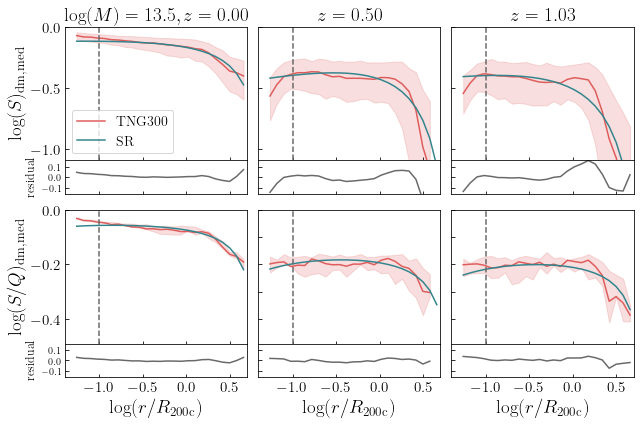

In [92]:
plot_single_mass(sdm=est_sdm, sdm_qdm=est_sdm_qdm, error=13.5, pred_m=13.5, islog=True)

In [100]:
valid_indices = ~np.isnan(y_train_sdm)
X_train = X_train_rad[valid_indices]
y_train = y_train_sdm[valid_indices]

score_sdm = est_sdm.score(X_train, y_train)
print('R2:', score_sdm)

R2: 0.941124437701155


In [101]:
valid_indices = ~np.isnan(y_train_sdm_qdm)
X_train = X_train_rad[valid_indices]
y_train = y_train_sdm_qdm[valid_indices]

score_sdm = est_sdm_qdm.score(X_train, y_train)
print('R2:', score_sdm)

R2: 0.9028346627145261
